# Stage 2 — Embedding

## SANAD Retrieval Evaluation

This notebook combines the completed Stage 2 embedding work for:

1. **Qwen3-Embedding-0.6B**
2. **BGE-M3**
3. **Final Model Comparison**

**Saved run outputs are preserved inside this notebook.**
You do **not** need to rerun the notebook just to view the completed results.

### Final Results

| Model | Recall@3 | Recall@5 | MRR | Avg. Retrieval Time |
|---|---:|---:|---:|---:|
| Qwen3-Embedding-0.6B | 0.7167 | 0.7333 | 0.6398 | 5.1544 s |
| BGE-M3 | 0.7833 | 0.8500 | 0.7084 | 0.5608 s |

**Retrieval-quality result:** BGE-M3 achieved higher Recall@3, Recall@5, and MRR on the shared 60-query SANAD test set.

> Timing should only be compared directly when both runs used equivalent hardware/runtime conditions.


# Part 1 — Qwen3-Embedding-0.6B

The following cells are the completed Qwen3 experiment with the original saved run outputs.


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving saudi_legal_moj_clean.parquet to saudi_legal_moj_clean.parquet
Saving qwen3_saudi_legal.index to qwen3_saudi_legal.index


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'saudi_legal_moj_clean.parquet', 'qwen3_saudi_legal.index', 'sample_data']


In [ ]:
!pip install -q faiss-cpu pyarrow

import pandas as pd
import faiss

df_clean = pd.read_parquet(
    "/content/saudi_legal_moj_clean.parquet"
).reset_index(drop=True)

qwen_index = faiss.read_index(
    "/content/qwen3_saudi_legal.index"
)

print("Dataset rows:", len(df_clean))
print("Indexed vectors:", qwen_index.ntotal)
print("Vector dimension:", qwen_index.d)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 80.1 MB/s eta 0:00:00
Dataset rows: 4226
Indexed vectors: 4226
Vector dimension: 1024


In [ ]:
!pip install -q -U sentence-transformers transformers accelerate

import torch
from sentence_transformers import SentenceTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"

qwen_model = SentenceTransformer(
    "Qwen/Qwen3-Embedding-0.6B",
    device=device
)

print("Model loaded successfully ✅")
print("Device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.6/740.6 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 25.1 MB/s eta 0:00:00


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/17.2k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

Model loaded successfully ✅
Device: cpu


In [ ]:
import numpy as np
import time

# سؤال تجريبي
query = "وش القضايا اللي ما عليها تكاليف قضائية؟"

# تعليمات ثابتة للمودل
query_for_embedding = (
    "Instruct: Retrieve the most relevant Saudi legal article for the given Arabic legal question.\n"
    f"Query: {query}"
)

# نحسب وقت تحويل السؤال + البحث
start_time = time.perf_counter()

query_embedding = qwen_model.encode(
    [query_for_embedding],
    normalize_embeddings=True
)

query_embedding = np.asarray(
    query_embedding,
    dtype="float32"
)

# نجيب أفضل 5 نتائج
scores, indices = qwen_index.search(
    query_embedding,
    5
)

elapsed_time = time.perf_counter() - start_time

print("Question:", query)
print("\nTop 5 Results:\n")

for rank, (idx, score) in enumerate(zip(indices[0], scores[0]), start=1):
    row = df_clean.iloc[idx]

    print(f"Rank {rank}")
    print("Law:", row["law_name"])
    print("Article:", row["article_number"])
    print("Score:", round(float(score), 4))
    print("Text:", str(row["text"])[:300])
    print("-" * 80)

print(f"\nRetrieval Time: {elapsed_time:.4f} seconds")

Question: وش القضايا اللي ما عليها تكاليف قضائية؟

Top 5 Results:

Rank 1
Law: نظام التكاليف القضائية
Article: المادة الثالثة
Score: 0.6666
Text: المادة الثالثة
تفرض تكاليف قضائية على الدعوى بمبلغ لا يزيد على ما نسبته (590) من قيمة المطالبة» وبحد أعلى مبلغ مليون ريال. وتحدد اللائحة معايير تقدير التكاليف القضائيةوالضوابط
والقواعد المنظمةلذلك.
--------------------------------------------------------------------------------
Rank 2
Law: نظام التكاليف القضائية
Article: المادة التاسعةعشرة
Score: 0.6585
Text: المادة التاسعةعشرة
تودع مبالغ التكاليف القضائية المحصلة في حساب جاري وزارة المالية لدى البنك المركزيالسعودي.
--------------------------------------------------------------------------------
Rank 3
Law: اللائحة التنفيذية لنظام التكاليف القضائية
Article: المادة العاشرة
Score: 0.648
Text: المادة العاشرة
تحتسب التكاليف القضائية بالربال السعودي» ولا يحتسب الجزء من الربال في تقديرالتكاليف.
4 00 1 ٠
الفصل الرابع: أحكامختاميه
----------------------------------------------------------------------

In [ ]:
import numpy as np

query = "وش القضايا اللي ما عليها تكاليف قضائية؟"

query_for_embedding = (
    "Instruct: Retrieve the most relevant Saudi legal article for the given Arabic legal question.\n"
    f"Query: {query}"
)

query_embedding = qwen_model.encode(
    [query_for_embedding],
    normalize_embeddings=True
)

query_embedding = np.asarray(query_embedding, dtype="float32")

# نبحث في كل الـ 4226 سجل
scores, indices = qwen_index.search(
    query_embedding,
    qwen_index.ntotal
)

gold_law = "نظام التكاليف القضائية"
gold_article = "المادة الثانية"

gold_rank = None
gold_score = None

for rank, (idx, score) in enumerate(
    zip(indices[0], scores[0]),
    start=1
):
    row = df_clean.iloc[idx]

    if (
        str(row["law_name"]).strip() == gold_law
        and str(row["article_number"]).strip() == gold_article
    ):
        gold_rank = rank
        gold_score = float(score)
        break

print("Gold Law:", gold_law)
print("Gold Article:", gold_article)
print("Gold Rank:", gold_rank)
print("Gold Score:", gold_score)

Gold Law: نظام التكاليف القضائية
Gold Article: المادة الثانية
Gold Rank: 29
Gold Score: 0.5492474436759949


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving SANAD_Retrieval_Test_Set_60.xlsx to SANAD_Retrieval_Test_Set_60.xlsx


In [ ]:
import pandas as pd

test_df = pd.read_excel(
    "/content/SANAD_Retrieval_Test_Set_60.xlsx",
    sheet_name="Test_Set"
)

print("Number of test questions:", len(test_df))
display(test_df.head())

Number of test questions: 60


,query_id,group_id,query_type,query,gold_law,gold_article,gold_key
0,Q001,G01,formal_direct,ما الدعاوى والطلبات التي لا تسري عليها أحكام ا...,نظام التكاليف القضائية,المادة الثانية,نظامالتكاليفالقضائية|المادةالثانية
1,Q002,G01,formal_paraphrase,ما الحالات المستثناة من تطبيق نظام التكاليف ال...,نظام التكاليف القضائية,المادة الثانية,نظامالتكاليفالقضائية|المادةالثانية
2,Q003,G01,informal,وش القضايا اللي ما عليها تكاليف قضائية؟,نظام التكاليف القضائية,المادة الثانية,نظامالتكاليفالقضائية|المادةالثانية
3,Q004,G02,formal_direct,ما الحد الأعلى للتكاليف القضائية المفروضة على ...,نظام التكاليف القضائية,المادة الثالثة,نظامالتكاليفالقضائية|المادةالثالثة
4,Q005,G02,formal_paraphrase,كيف يتم تحديد قيمة التكاليف القضائية بالنسبة إ...,نظام التكاليف القضائية,المادة الثالثة,نظامالتكاليفالقضائية|المادةالثالثة


In [ ]:
import time
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# --------------------------------------------------
# 1) Warm-up
# عشان أول تشغيل للمودل ما يخرب حساب الوقت
# --------------------------------------------------

warmup_query = (
    "Instruct: Retrieve the most relevant Saudi legal article for the given Arabic legal question.\n"
    "Query: ما حقوق العامل؟"
)

_ = qwen_model.encode(
    [warmup_query],
    normalize_embeddings=True
)

print("Warm-up completed ✅")


# --------------------------------------------------
# 2) تشغيل جميع الأسئلة
# --------------------------------------------------

results = []

for _, test_row in tqdm(
    test_df.iterrows(),
    total=len(test_df),
    desc="Evaluating Qwen3"
):

    query_id = test_row["query_id"]
    query_type = test_row["query_type"]
    query = str(test_row["query"])

    gold_law = str(test_row["gold_law"]).strip()
    gold_article = str(test_row["gold_article"]).strip()

    query_for_embedding = (
        "Instruct: Retrieve the most relevant Saudi legal article "
        "for the given Arabic legal question.\n"
        f"Query: {query}"
    )

    # -------------------------
    # قياس الوقت
    # -------------------------
    start_time = time.perf_counter()

    query_embedding = qwen_model.encode(
        [query_for_embedding],
        normalize_embeddings=True
    )

    query_embedding = np.asarray(
        query_embedding,
        dtype="float32"
    )

    # نبحث في كل الـ index
    # عشان نعرف Gold Rank الحقيقي
    scores, indices = qwen_index.search(
        query_embedding,
        qwen_index.ntotal
    )

    elapsed_time = time.perf_counter() - start_time

    # -------------------------
    # البحث عن ترتيب Gold Article
    # -------------------------
    gold_rank = None

    for rank, idx in enumerate(indices[0], start=1):

        retrieved_row = df_clean.iloc[idx]

        retrieved_law = str(
            retrieved_row["law_name"]
        ).strip()

        retrieved_article = str(
            retrieved_row["article_number"]
        ).strip()

        if (
            retrieved_law == gold_law
            and retrieved_article == gold_article
        ):
            gold_rank = rank
            break

    # -------------------------
    # Metrics لكل سؤال
    # -------------------------
    recall_at_3 = int(
        gold_rank is not None and gold_rank <= 3
    )

    recall_at_5 = int(
        gold_rank is not None and gold_rank <= 5
    )

    reciprocal_rank = (
        1 / gold_rank
        if gold_rank is not None
        else 0
    )

    # -------------------------
    # Top 5 Results
    # -------------------------
    top5 = []

    for rank in range(5):

        idx = indices[0][rank]
        score = scores[0][rank]

        retrieved_row = df_clean.iloc[idx]

        top5.append({
            "law": str(retrieved_row["law_name"]),
            "article": str(retrieved_row["article_number"]),
            "score": float(score)
        })

    # -------------------------
    # حفظ النتائج
    # -------------------------
    result = {
        "query_id": query_id,
        "query_type": query_type,
        "query": query,

        "gold_law": gold_law,
        "gold_article": gold_article,

        "gold_rank": gold_rank,

        "Recall@3": recall_at_3,
        "Recall@5": recall_at_5,
        "Reciprocal_Rank": reciprocal_rank,

        "Time_seconds": elapsed_time,
    }

    # إضافة Top-5 للجدول
    for i, item in enumerate(top5, start=1):

        result[f"Top{i}_Law"] = item["law"]
        result[f"Top{i}_Article"] = item["article"]
        result[f"Top{i}_Score"] = item["score"]

    results.append(result)


# --------------------------------------------------
# 3) تحويل النتائج إلى DataFrame
# --------------------------------------------------

results_df = pd.DataFrame(results)

print("\nFinished ✅")
print("Questions evaluated:", len(results_df))

Warm-up completed ✅


Evaluating Qwen3:   0%|          | 0/60 [00:00<?, ?it/s]


Finished ✅
Questions evaluated: 60


In [ ]:
# -----------------------------------
# Final Metrics
# -----------------------------------

recall_at_3 = results_df["Recall@3"].mean()
recall_at_5 = results_df["Recall@5"].mean()
mrr = results_df["Reciprocal_Rank"].mean()
avg_time = results_df["Time_seconds"].mean()

print("Qwen3-Embedding-0.6B Results")
print("-" * 40)

print(f"Recall@3: {recall_at_3:.4f}")
print(f"Recall@5: {recall_at_5:.4f}")
print(f"MRR: {mrr:.4f}")
print(f"Average Retrieval Time: {avg_time:.4f} seconds")


# -----------------------------------
# Results by Query Type
# -----------------------------------

type_results = results_df.groupby("query_type").agg(
    Recall_at_3=("Recall@3", "mean"),
    Recall_at_5=("Recall@5", "mean"),
    MRR=("Reciprocal_Rank", "mean"),
    Avg_Time=("Time_seconds", "mean")
)

print("\nResults by Query Type:")
display(type_results)


# -----------------------------------
# Save detailed results
# -----------------------------------

results_df.to_csv(
    "/content/qwen3_retrieval_results.csv",
    index=False,
    encoding="utf-8-sig"
)

type_results.to_csv(
    "/content/qwen3_results_by_query_type.csv",
    encoding="utf-8-sig"
)

print("\nFiles saved ✅")
print("qwen3_retrieval_results.csv")
print("qwen3_results_by_query_type.csv")

Qwen3-Embedding-0.6B Results
----------------------------------------
Recall@3: 0.7167
Recall@5: 0.7333
MRR: 0.6398
Average Retrieval Time: 5.1544 seconds

Results by Query Type:


,Recall_at_3,Recall_at_5,MRR,Avg_Time
query_type,,,,
formal_direct,0.80,0.80,0.699222,5.033986
formal_paraphrase,0.75,0.75,0.670725,5.000703
informal,0.60,0.65,0.549455,5.428558



Files saved ✅
qwen3_retrieval_results.csv
qwen3_results_by_query_type.csv


In [ ]:
from google.colab import files

files.download("/content/qwen3_retrieval_results.csv")
files.download("/content/qwen3_results_by_query_type.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Part 2 — BGE-M3

The following cells are the completed BGE-M3 experiment with the original saved run outputs.

The BGE document representation matches the Qwen experiment:

`law_name + article_number + text`


# BGE-M3 — SANAD Retrieval Evaluation

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving saudi_legal_moj_clean.parquet to saudi_legal_moj_clean.parquet


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'saudi_legal_moj_clean.parquet', 'sample_data']


In [ ]:
!pip install -q faiss-cpu pyarrow

import pandas as pd

df_clean = pd.read_parquet(
    "/content/saudi_legal_moj_clean.parquet"
).reset_index(drop=True)

print("Dataset rows:", len(df_clean))
print("Columns:", df_clean.columns.tolist())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 23.5 MB/s eta 0:00:00
Dataset rows: 4226
Columns: ['law_name', 'law_type', 'article_number', 'text', 'source', 'article_key', 'text_norm', 'needs_manual_review', 'embedding_text']


In [ ]:
!pip install -q -U sentence-transformers transformers accelerate

import torch
from sentence_transformers import SentenceTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"

bge_model = SentenceTransformer(
    "BAAI/bge-m3",
    device=device
)

bge_model.max_seq_length = 2048

print("Model loaded successfully ✅")
print("Device:", device)
print("Embedding dimension:", bge_model.get_sentence_embedding_dimension())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.6/740.6 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 20.2 MB/s eta 0:00:00


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Model loaded successfully ✅
Device: cpu
Embedding dimension: 1024


/tmp/ipykernel_860/3154063169.py:17: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print("Embedding dimension:", bge_model.get_sentence_embedding_dimension())


## بناء الـ FAISS Index لـ BGE-M3

In [ ]:
import time
import numpy as np
import faiss

def build_doc_text(row):
    # نفس صيغة تمثيل الوثيقة المستخدمة في Qwen لضمان مقارنة عادلة
    return (
        "اسم النظام: " + str(row["law_name"]) +
        "\nرقم المادة: " + str(row["article_number"]) +
        "\nالنص القانوني: " + str(row["text"])
    )

docs = [build_doc_text(row) for _, row in df_clean.iterrows()]

start = time.perf_counter()

# BGE-M3 ما يحتاج Instruction للوثائق
doc_embeddings = bge_model.encode(
    docs,
    batch_size=16,
    normalize_embeddings=True,
    show_progress_bar=True
)

doc_embeddings = np.asarray(doc_embeddings, dtype="float32")

# Inner Product مع vectors مطبّعة = Cosine Similarity
bge_index = faiss.IndexFlatIP(doc_embeddings.shape[1])
bge_index.add(doc_embeddings)

print(f"\nIndexing time: {time.perf_counter() - start:.1f} seconds")


print("Indexed vectors:", bge_index.ntotal)
print("Vector dimension:", bge_index.d)

# نحفظ الـ index عشان ما نعيد البناء كل مرة
faiss.write_index(bge_index, "/content/bge_m3_saudi_legal.index")
print("Index saved ✅")

Batches:   0%|          | 0/265 [00:00<?, ?it/s]


Indexing time: 7902.8 seconds
Indexed vectors: 4226
Vector dimension: 1024
Index saved ✅


In [ ]:
from google.colab import files

# اختياري: نزّل الـ index عشان تستخدمه لاحقاً بدون إعادة بناء
files.download("/content/bge_m3_saudi_legal.index")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import time

# سؤال تجريبي
query = "وش القضايا اللي ما عليها تكاليف قضائية؟"

# BGE-M3 ما يحتاج Instruction للسؤال، نمرر السؤال كما هو
start_time = time.perf_counter()

query_embedding = bge_model.encode(
    [query],
    normalize_embeddings=True
)

query_embedding = np.asarray(
    query_embedding,
    dtype="float32"
)

# نجيب أفضل 5 نتائج
scores, indices = bge_index.search(
    query_embedding,
    5
)

elapsed_time = time.perf_counter() - start_time

print("Question:", query)
print("\nTop 5 Results:\n")

for rank, (idx, score) in enumerate(zip(indices[0], scores[0]), start=1):
    row = df_clean.iloc[idx]

    print(f"Rank {rank}")
    print("Law:", row["law_name"])
    print("Article:", row["article_number"])
    print("Score:", round(float(score), 4))
    print("Text:", str(row["text"])[:300])
    print("-" * 80)

print(f"\nRetrieval Time: {elapsed_time:.4f} seconds")

Question: وش القضايا اللي ما عليها تكاليف قضائية؟

Top 5 Results:

Rank 1
Law: نظام التكاليف القضائية
Article: المادة السابعةعشرة
Score: 0.6451
Text: المادة السابعةعشرة
مع مراعاة ما تقضي به الأنظمة والمعاهدات والاتفاقيات الدولية التي تكون المملكة طرفاًء لا تفرض التكاليف القضائية على الفئاتالآتية:
١.المسجونون والموقوفون وقت استحقاق التكاليف القضائية في قضايا مالية غير جنائية» في الدعاوى التي تقام سواءً كانت منهم أوعليهم.
".العمال المشمولون بنظام ا
--------------------------------------------------------------------------------
Rank 2
Law: نظام التكاليف القضائية
Article: المادة العاشرة
Score: 0.6341
Text: المادة العاشرة
لاتفرض تكاليف جديدة على الدعوى في أي من الحالتينالآتيتين:
١.إذا حكم بعدم الاختصاص وأقيمت الدعوى أمام المحكمةالمختصة.
؟.إذا قضت المحكمة المختصة بنقض الحكم وإعادة الدعوى إلى المحكمة التي أصدرت الحكم المعترض عليه أو إلى محكمةأخرى.
--------------------------------------------------------------------------------
Rank 3
Law: اللائحة التنفيذية لنظام التكاليف القضائية
Article: ال

In [ ]:
import numpy as np

query = "وش القضايا اللي ما عليها تكاليف قضائية؟"

query_embedding = bge_model.encode(
    [query],
    normalize_embeddings=True
)

query_embedding = np.asarray(query_embedding, dtype="float32")

# نبحث في كل السجلات
scores, indices = bge_index.search(
    query_embedding,
    bge_index.ntotal
)

gold_law = "نظام التكاليف القضائية"
gold_article = "المادة الثانية"

gold_rank = None
gold_score = None

for rank, (idx, score) in enumerate(
    zip(indices[0], scores[0]),
    start=1
):
    row = df_clean.iloc[idx]

    if (
        str(row["law_name"]).strip() == gold_law
        and str(row["article_number"]).strip() == gold_article
    ):
        gold_rank = rank
        gold_score = float(score)
        break

print("Gold Law:", gold_law)
print("Gold Article:", gold_article)
print("Gold Rank:", gold_rank)
print("Gold Score:", gold_score)

Gold Law: نظام التكاليف القضائية
Gold Article: المادة الثانية
Gold Rank: 9
Gold Score: 0.5730053186416626


In [ ]:
from google.colab import files
import os

uploaded = files.upload()
print(os.listdir("/content"))

Saving SANAD_Retrieval_Test_Set_60.xlsx to SANAD_Retrieval_Test_Set_60 (1).xlsx
['.config', 'saudi_legal_moj_clean.parquet', 'SANAD_Retrieval_Test_Set_60 (1).xlsx', 'bge_m3_saudi_legal.index', 'SANAD_Retrieval_Test_Set_60.xlsx', 'sample_data']


In [ ]:
import pandas as pd

test_df = pd.read_excel(
    "/content/SANAD_Retrieval_Test_Set_60.xlsx",
    sheet_name="Test_Set"
)

print("Number of test questions:", len(test_df))
display(test_df.head())

Number of test questions: 60


,query_id,group_id,query_type,query,gold_law,gold_article,gold_key
0,Q001,G01,formal_direct,ما الدعاوى والطلبات التي لا تسري عليها أحكام ا...,نظام التكاليف القضائية,المادة الثانية,نظامالتكاليفالقضائية|المادةالثانية
1,Q002,G01,formal_paraphrase,ما الحالات المستثناة من تطبيق نظام التكاليف ال...,نظام التكاليف القضائية,المادة الثانية,نظامالتكاليفالقضائية|المادةالثانية
2,Q003,G01,informal,وش القضايا اللي ما عليها تكاليف قضائية؟,نظام التكاليف القضائية,المادة الثانية,نظامالتكاليفالقضائية|المادةالثانية
3,Q004,G02,formal_direct,ما الحد الأعلى للتكاليف القضائية المفروضة على ...,نظام التكاليف القضائية,المادة الثالثة,نظامالتكاليفالقضائية|المادةالثالثة
4,Q005,G02,formal_paraphrase,كيف يتم تحديد قيمة التكاليف القضائية بالنسبة إ...,نظام التكاليف القضائية,المادة الثالثة,نظامالتكاليفالقضائية|المادةالثالثة


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [ ]:
import time
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# --------------------------------------------------
# 1) Warm-up
# عشان أول تشغيل للمودل ما يخرب حساب الوقت
# --------------------------------------------------

_ = bge_model.encode(
    ["ما حقوق العامل؟"],
    normalize_embeddings=True
)

print("Warm-up completed ✅")


# --------------------------------------------------
# 2) تشغيل جميع الأسئلة
# --------------------------------------------------

results = []

for _, test_row in tqdm(
    test_df.iterrows(),
    total=len(test_df),
    desc="Evaluating BGE-M3"
):

    query_id = test_row["query_id"]
    query_type = test_row["query_type"]
    query = str(test_row["query"])

    gold_law = str(test_row["gold_law"]).strip()
    gold_article = str(test_row["gold_article"]).strip()

    # -------------------------
    # قياس الوقت (تحويل السؤال + البحث)
    # -------------------------
    start_time = time.perf_counter()

    query_embedding = bge_model.encode(
        [query],
        normalize_embeddings=True
    )

    query_embedding = np.asarray(
        query_embedding,
        dtype="float32"
    )

    # نبحث في كل الـ index
    # عشان نعرف Gold Rank الحقيقي
    scores, indices = bge_index.search(
        query_embedding,
        bge_index.ntotal
    )

    elapsed_time = time.perf_counter() - start_time

    # -------------------------
    # البحث عن ترتيب Gold Article
    # -------------------------
    gold_rank = None

    for rank, idx in enumerate(indices[0], start=1):

        retrieved_row = df_clean.iloc[idx]

        retrieved_law = str(
            retrieved_row["law_name"]
        ).strip()

        retrieved_article = str(
            retrieved_row["article_number"]
        ).strip()

        if (
            retrieved_law == gold_law
            and retrieved_article == gold_article
        ):
            gold_rank = rank
            break

    # -------------------------
    # Metrics لكل سؤال
    # -------------------------
    recall_at_3 = int(
        gold_rank is not None and gold_rank <= 3
    )

    recall_at_5 = int(
        gold_rank is not None and gold_rank <= 5
    )

    reciprocal_rank = (
        1 / gold_rank
        if gold_rank is not None
        else 0
    )

    # -------------------------
    # Top 5 Results
    # -------------------------
    top5 = []

    for rank in range(5):

        idx = indices[0][rank]
        score = scores[0][rank]

        retrieved_row = df_clean.iloc[idx]

        top5.append({
            "law": str(retrieved_row["law_name"]),
            "article": str(retrieved_row["article_number"]),
            "score": float(score)
        })

    # -------------------------
    # حفظ النتائج
    # -------------------------
    result = {
        "query_id": query_id,
        "query_type": query_type,
        "query": query,

        "gold_law": gold_law,
        "gold_article": gold_article,

        "gold_rank": gold_rank,

        "Recall@3": recall_at_3,
        "Recall@5": recall_at_5,
        "Reciprocal_Rank": reciprocal_rank,

        "Time_seconds": elapsed_time,
    }

    # إضافة Top-5 للجدول
    for i, item in enumerate(top5, start=1):

        result[f"Top{i}_Law"] = item["law"]
        result[f"Top{i}_Article"] = item["article"]
        result[f"Top{i}_Score"] = item["score"]

    results.append(result)


# --------------------------------------------------
# 3) تحويل النتائج إلى DataFrame
# --------------------------------------------------

results_df = pd.DataFrame(results)

print("\nFinished ✅")
print("Questions evaluated:", len(results_df))

Warm-up completed ✅


Evaluating BGE-M3:   0%|          | 0/60 [00:00<?, ?it/s]


Finished ✅
Questions evaluated: 60


In [ ]:
# -----------------------------------
# Final Metrics
# -----------------------------------

recall_at_3 = results_df["Recall@3"].mean()
recall_at_5 = results_df["Recall@5"].mean()
mrr = results_df["Reciprocal_Rank"].mean()
avg_time = results_df["Time_seconds"].mean()

print("BGE-M3 Results")
print("-" * 40)

print(f"Recall@3: {recall_at_3:.4f}")
print(f"Recall@5: {recall_at_5:.4f}")
print(f"MRR: {mrr:.4f}")
print(f"Average Retrieval Time: {avg_time:.4f} seconds")


# -----------------------------------
# Results by Query Type
# -----------------------------------

type_results = results_df.groupby("query_type").agg(
    Recall_at_3=("Recall@3", "mean"),
    Recall_at_5=("Recall@5", "mean"),
    MRR=("Reciprocal_Rank", "mean"),
    Avg_Time=("Time_seconds", "mean")
)

print("\nResults by Query Type:")
display(type_results)


# -----------------------------------
# Save detailed results
# -----------------------------------

results_df.to_csv(
    "/content/bge_m3_retrieval_results.csv",
    index=False,
    encoding="utf-8-sig"
)

type_results.to_csv(
    "/content/bge_m3_results_by_query_type.csv",
    encoding="utf-8-sig"
)

print("\nFiles saved ✅")
print("bge_m3_retrieval_results.csv")
print("bge_m3_results_by_query_type.csv")

BGE-M3 Results
----------------------------------------
Recall@3: 0.7833
Recall@5: 0.8500
MRR: 0.7084
Average Retrieval Time: 0.5608 seconds

Results by Query Type:


,Recall_at_3,Recall_at_5,MRR,Avg_Time
query_type,,,,
formal_direct,0.90,0.90,0.791667,0.624536
formal_paraphrase,0.75,0.85,0.653056,0.548274
informal,0.70,0.80,0.680556,0.509673



Files saved ✅
bge_m3_retrieval_results.csv
bge_m3_results_by_query_type.csv


In [ ]:
from google.colab import files

files.download("/content/bge_m3_retrieval_results.csv")
files.download("/content/bge_m3_results_by_query_type.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Part 3 — Final Embedding Model Comparison

This section contains the completed comparison, charts, final conclusion, and Excel-generation code with the saved outputs.


# SANAD — Embedding Model Comparison

This notebook combines the final retrieval evaluation results for:

- **Qwen3-Embedding-0.6B**
- **BGE-M3**

Both models were evaluated using the **same 4,226 clean Saudi legal records**, the **same 60 test queries**, the **same gold law/article labels**, and the **same document representation**:

`law_name + article_number + text`

The notebook compares **Recall@3, Recall@5, MRR, retrieval time, and performance by query type**, then creates the final Excel comparison file automatically.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


## 1. Overall Results

In [2]:
overall = pd.DataFrame({
    "Metric": ["Recall@3", "Recall@5", "MRR", "Average Retrieval Time (s)"],
    "Qwen3-Embedding-0.6B": [0.7167, 0.7333, 0.6398, 5.1544],
    "BGE-M3": [0.7833, 0.8500, 0.7084, 0.5608]
})

overall["Difference (BGE - Qwen)"] = (
    overall["BGE-M3"] - overall["Qwen3-Embedding-0.6B"]
)

overall["Better Result"] = [
    "BGE-M3",
    "BGE-M3",
    "BGE-M3",
    "BGE-M3"
]

display(overall)


,Metric,Qwen3-Embedding-0.6B,BGE-M3,Difference (BGE - Qwen),Better Result
0,Recall@3,0.7167,0.7833,0.0666,BGE-M3
1,Recall@5,0.7333,0.8500,0.1167,BGE-M3
2,MRR,0.6398,0.7084,0.0686,BGE-M3
3,Average Retrieval Time (s),5.1544,0.5608,-4.5936,BGE-M3


In [3]:
qwen_top3 = round(0.7167 * 60)
bge_top3 = round(0.7833 * 60)

qwen_top5 = round(0.7333 * 60)
bge_top5 = round(0.8500 * 60)

success_counts = pd.DataFrame({
    "Metric": ["Correct within Top-3", "Correct within Top-5"],
    "Qwen3": [qwen_top3, qwen_top5],
    "BGE-M3": [bge_top3, bge_top5]
})

display(success_counts)


,Metric,Qwen3,BGE-M3
0,Correct within Top-3,43,47
1,Correct within Top-5,44,51


## 2. Results by Query Type

In [4]:
by_type = pd.DataFrame({
    "Query Type": ["formal_direct", "formal_paraphrase", "informal"],
    "Qwen Recall@3": [0.80, 0.75, 0.60],
    "BGE Recall@3": [0.90, 0.75, 0.70],
    "Qwen Recall@5": [0.80, 0.75, 0.65],
    "BGE Recall@5": [0.90, 0.85, 0.80],
    "Qwen MRR": [0.699222, 0.670725, 0.549455],
    "BGE MRR": [0.791667, 0.653056, 0.680556],
    "Qwen Avg Time (s)": [5.033986, 5.000703, 5.428558],
    "BGE Avg Time (s)": [0.624536, 0.548274, 0.509673]
})

display(by_type)


,Query Type,Qwen Recall@3,BGE Recall@3,Qwen Recall@5,BGE Recall@5,Qwen MRR,BGE MRR,Qwen Avg Time (s),BGE Avg Time (s)
0,formal_direct,0.80,0.90,0.80,0.90,0.699222,0.791667,5.033986,0.624536
1,formal_paraphrase,0.75,0.75,0.75,0.85,0.670725,0.653056,5.000703,0.548274
2,informal,0.60,0.70,0.65,0.80,0.549455,0.680556,5.428558,0.509673


## 3. Comparison Charts

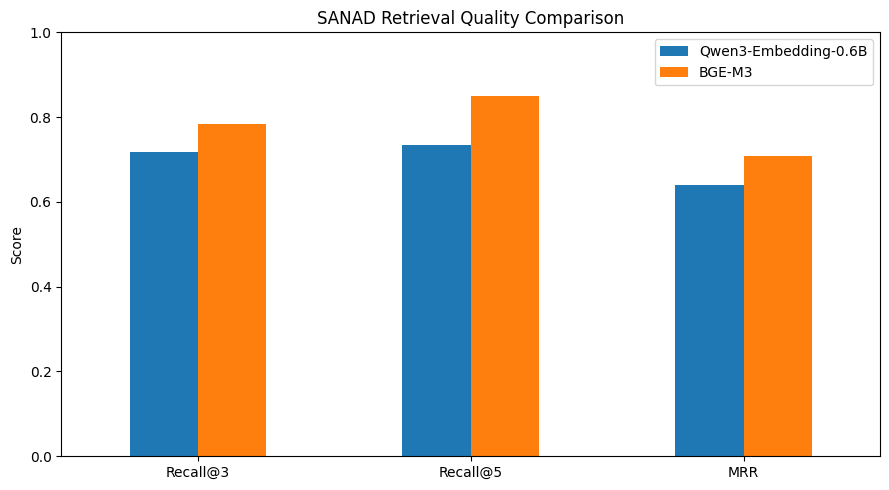

In [5]:
quality = overall.iloc[:3].set_index("Metric")[
    ["Qwen3-Embedding-0.6B", "BGE-M3"]
]

ax = quality.plot(kind="bar", figsize=(9, 5))
ax.set_title("SANAD Retrieval Quality Comparison")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


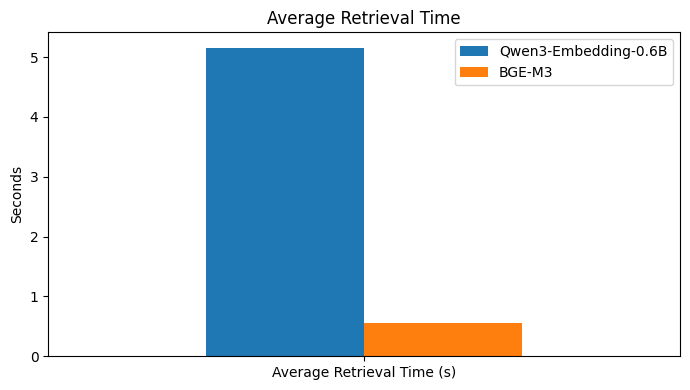

Note: timing should be compared directly only when both models run under equivalent hardware/runtime conditions.


In [6]:
time_df = overall.iloc[[3]].set_index("Metric")[
    ["Qwen3-Embedding-0.6B", "BGE-M3"]
]

ax = time_df.plot(kind="bar", figsize=(7, 4))
ax.set_title("Average Retrieval Time")
ax.set_ylabel("Seconds")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Note: timing should be compared directly only when both models run under equivalent hardware/runtime conditions.")


## 4. Final Experimental Conclusion

On the shared 60-query SANAD retrieval test set:

- **BGE-M3 Recall@3:** 0.7833 vs Qwen3: 0.7167
- **BGE-M3 Recall@5:** 0.8500 vs Qwen3: 0.7333
- **BGE-M3 MRR:** 0.7084 vs Qwen3: 0.6398
- BGE-M3 also achieved higher Recall@5 for **formal direct, formal paraphrase, and informal queries**.

Therefore, based on this experiment, **BGE-M3 produced the stronger retrieval quality for SANAD**.

> Retrieval-time results should only be interpreted as a direct speed comparison if both runs used equivalent hardware and runtime conditions.


## 5. Create the Final Excel File

In [7]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.chart import BarChart, Reference

excel_path = "/content/SANAD_Embedding_Model_Comparison.xlsx"

wb = Workbook()

# ---------------- Overall Comparison ----------------
ws = wb.active
ws.title = "Overall_Comparison"

title_fill = PatternFill("solid", fgColor="1F4E78")
header_fill = PatternFill("solid", fgColor="D9EAF7")
green_fill = PatternFill("solid", fgColor="E2F0D9")

ws.merge_cells("A1:F1")
ws["A1"] = "SANAD — Embedding Retrieval Model Comparison"
ws["A1"].font = Font(bold=True, color="FFFFFF", size=16)
ws["A1"].fill = title_fill
ws["A1"].alignment = Alignment(horizontal="center")

headers = [
    "Metric",
    "Qwen3-Embedding-0.6B",
    "BGE-M3",
    "Difference (BGE - Qwen)",
    "Better Result",
    "Note"
]

for col, header in enumerate(headers, 1):
    cell = ws.cell(row=3, column=col, value=header)
    cell.font = Font(bold=True)
    cell.fill = header_fill
    cell.alignment = Alignment(horizontal="center")

comparison_rows = [
    ["Recall@3", 0.7167, 0.7833, 0.7833 - 0.7167, "BGE-M3", "Higher is better"],
    ["Recall@5", 0.7333, 0.8500, 0.8500 - 0.7333, "BGE-M3", "Higher is better"],
    ["MRR", 0.6398, 0.7084, 0.7084 - 0.6398, "BGE-M3", "Higher is better"],
    ["Average Retrieval Time (s)", 5.1544, 0.5608, 0.5608 - 5.1544, "BGE-M3",
     "Lower is better; timing is directly comparable only under equivalent hardware/runtime conditions"]
]

for row_idx, row in enumerate(comparison_rows, 4):
    for col_idx, value in enumerate(row, 1):
        ws.cell(row=row_idx, column=col_idx, value=value)

for row_idx in range(4, 7):
    for col_idx in [2, 3, 4]:
        ws.cell(row_idx, col_idx).number_format = "0.00%"

for col_idx in [2, 3, 4]:
    ws.cell(7, col_idx).number_format = "0.0000"

ws["A9"] = "Top-k Success Counts"
ws["B9"] = "Qwen3"
ws["C9"] = "BGE-M3"

for cell in ws[9][:3]:
    cell.font = Font(bold=True)
    cell.fill = header_fill

ws["A10"] = "Correct within Top-3 (out of 60)"
ws["B10"] = 43
ws["C10"] = 47

ws["A11"] = "Correct within Top-5 (out of 60)"
ws["B11"] = 44
ws["C11"] = 51

ws.merge_cells("A13:F13")
ws["A13"] = (
    "Final experimental result: BGE-M3 achieved higher Recall@3, "
    "Recall@5, and MRR on the shared 60-query SANAD test set."
)
ws["A13"].font = Font(bold=True)
ws["A13"].fill = green_fill
ws["A13"].alignment = Alignment(horizontal="center", wrap_text=True)

for col, width in {
    "A": 30, "B": 24, "C": 18,
    "D": 24, "E": 18, "F": 55
}.items():
    ws.column_dimensions[col].width = width

chart = BarChart()
chart.type = "col"
chart.title = "Retrieval Quality Comparison"
chart.y_axis.title = "Score"
chart.x_axis.title = "Metric"

data = Reference(ws, min_col=2, max_col=3, min_row=3, max_row=6)
categories = Reference(ws, min_col=1, min_row=4, max_row=6)

chart.add_data(data, titles_from_data=True)
chart.set_categories(categories)
chart.height = 8
chart.width = 14
ws.add_chart(chart, "H3")

# ---------------- Results by Query Type ----------------
ws2 = wb.create_sheet("By_Query_Type")

ws2.merge_cells("A1:I1")
ws2["A1"] = "SANAD — Retrieval Performance by Query Type"
ws2["A1"].font = Font(bold=True, color="FFFFFF", size=15)
ws2["A1"].fill = title_fill
ws2["A1"].alignment = Alignment(horizontal="center")

for col_idx, header in enumerate(by_type.columns, 1):
    cell = ws2.cell(row=3, column=col_idx, value=header)
    cell.font = Font(bold=True)
    cell.fill = header_fill
    cell.alignment = Alignment(horizontal="center")

for row_idx, row in enumerate(by_type.itertuples(index=False), 4):
    for col_idx, value in enumerate(row, 1):
        ws2.cell(row=row_idx, column=col_idx, value=value)

for row_idx in range(4, 7):
    for col_idx in range(2, 6):
        ws2.cell(row_idx, col_idx).number_format = "0.00%"
    for col_idx in range(6, 10):
        ws2.cell(row_idx, col_idx).number_format = "0.0000"

for col_idx in range(1, 10):
    ws2.column_dimensions[chr(64 + col_idx)].width = 20

# ---------------- Methodology ----------------
ws3 = wb.create_sheet("Methodology")

methodology = [
    ["Models compared", "Qwen3-Embedding-0.6B vs BGE-M3"],
    ["Dataset", "saudi_legal_moj_clean.parquet — 4,226 clean legal records"],
    ["Test set", "60 queries = 20 gold legal articles × 3 query formulations"],
    ["Query types", "formal_direct, formal_paraphrase, informal"],
    ["Document representation", "اسم النظام + رقم المادة + النص القانوني"],
    ["Index/Search", "FAISS with normalized embeddings"],
    ["Metrics", "Recall@3, Recall@5, MRR, Average Retrieval Time"],
    ["Fairness", "Same dataset, questions, gold labels, and document representation"],
    ["Timing note", "Compare time directly only under equivalent hardware/runtime conditions"]
]

ws3.append(["Item", "Details"])

for cell in ws3[1]:
    cell.font = Font(bold=True, color="FFFFFF")
    cell.fill = title_fill

for row in methodology:
    ws3.append(row)

ws3.column_dimensions["A"].width = 28
ws3.column_dimensions["B"].width = 90

for row in ws3.iter_rows():
    for cell in row:
        cell.alignment = Alignment(wrap_text=True, vertical="top")

wb.save(excel_path)

print("Excel file created successfully ✅")
print(excel_path)


Excel file created successfully ✅
/content/SANAD_Embedding_Model_Comparison.xlsx


In [8]:
# Run this cell in Google Colab to download the Excel file.
from google.colab import files
files.download("/content/SANAD_Embedding_Model_Comparison.xlsx")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>